# **LABORATORIO 1 DE REGRESION MULTIVARIABLE DEL DATASET "COCHES USADOS DE LOS UE"**

Este es el segundo conjunto de datos que creo sobre coches, esta vez con 40.000 entradas, lo que debería ser suficiente para realizar predicciones precisas de precios, más columnas, útiles para practicar la exploración de datos y la búsqueda de correlaciones, y una URL de imagen para cada coche, que podría usarse para el reconocimiento de imágenes. Dado que todos los datos fueron extraídos por mí con PlayWright, algunos podrían ser de un tipo incorrecto o contener entradas extrañas, por lo que recomiendo revisar el marco de datos y realizar los cambios necesarios para que esté limpio. ¡Que lo disfrutes!

X1 -> Make – marca del auto

X2 -> Model – modelo del auto

X3 -> Body – tipo de carrocería

X4 -> Mileage_km – kilometraje

X5 -> Year – año del auto

X6 -> Country – país donde se vende

X7 -> Condition – condición del auto

X8 -> Fuel_Type – tipo de combustible

X9 -> Fuel_Consum – consumo de combustible

X10 -> Drivetrain – tipo de tracción

X11 -> Gearbox – tipo de transmisión

X12 -> Gears – número de marchas

X13 -> Power_hp – potencia del motor

X14 -> Engine_Size_cc – tamaño del motor

X15 -> Cylinders – número de cilindros

X16 -> Seats – número de asientos

X17 -> Doors – número de puertas

X18 -> Upholstery – tipo de tapizado

X19 -> Full_Service_History – historial de servicio

X20 -> Previous_Owners – número de dueños anteriores

Y -> h(x) -> price - precio

In [9]:
#from google.colab import drive
#drive.mount('/content/drive')

importacion de librerias

In [10]:
# se utiliza para el manejo de rutas y directorios.
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot

In [11]:
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine learning/datasetslabs/fullGas.csv', delimiter=',')
df = pd.read_csv('fullGas.csv', delimiter=',')
df.head()

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...


## Tratamiento de Datos de Texto a Numero

Los siguintes campos que presentan datos en texto seran transformados sus datos a numeros:

* Make – marca del auto

* Model – modelo del auto

* Body – tipo de carrocería

* Year – año del auto

* Country – país donde se vende

* Condition – condición del auto

* Fuel_Type – tipo de combustible

* Fuel_Consum – consumo de combustible

* Drivetrain – tipo de tracción

* Gearbox – tipo de transmisión

* Gears – número de marchas

* Engine_Size_cc – tamaño del motor

* Cylinders – número de cilindros

* Seats – número de asientos

* Doors – número de puertas

* Upholstery – tipo de tapizado

* Full_Service_History – historial de servicio

* Previous_Owners – número de dueños anteriores

In [12]:
# 1. Cargar el dataset
#df = pd.read_csv('/content/drive/My Drive/tu_dataset.csv')

# 2. Calcular el promedio de precio por cada Marca (Make)
# Esto crea una "tabla de consulta" interna
mapeo_marcas = df.groupby('Make')['Price'].mean()
#print(mapeo_precios)
# 3. Aplicar la transformación
# Creamos una nueva columna llamada 'Make_Encoded'
df['Make_numeric'] = df['Make'].map(mapeo_marcas)

# 4. Ver los resultados del mapeo
#print("Muestra de la transformación:")
#print(df[['Make', 'Price', 'Make_Encoded']].head(10))

# 5. (Opcional) Ver las marcas más caras vs las más baratas
print("\nMarcas ordenadas por su valor promedio:")
print(mapeo_marcas.sort_values(ascending=False))

#6 imoresion de
#print("Impresion de make")
#print(df['Make_numeric'].head(10))


Marcas ordenadas por su valor promedio:
Make
Ferrari          409388.346154
Lamborghini      350511.398656
McLaren          338016.482063
Rolls-Royce      252246.850629
Aston Martin     231377.734628
Bentley          160694.266180
Corvette          93958.157980
Porsche           90245.042904
Maserati          48284.712375
Land Rover        47711.270358
Dodge             40566.847514
BYD               34691.751656
Jaguar            30862.097849
Lexus             30806.677026
CUPRA             30659.538376
Alfa Romeo        30578.578723
Tesla             29835.044593
Volvo             29306.793737
Mercedes-Benz     26064.782663
BMW               25314.842684
Citroen           25044.712314
Audi              24649.673961
Mazda             23483.828142
Skoda             22602.919393
Jeep              22497.422127
Toyota            22404.389610
Kia               21792.862983
MINI              21456.225736
Hyundai           20503.010262
MG                19757.421397
Chevrolet         19672.

In [13]:
# 1. Calcular el promedio de precio por cada Modelo existente
# (Pandas ignora automáticamente los valores nulos al agrupar)
mapeo_modelos = df.groupby('Model')['Price'].mean()

# 2. Aplicar la transformación a una nueva columna numérica
df['Model_numeric'] = df['Model'].map(mapeo_modelos)

# 3. LLENAR LOS VACÍOS CON 0
# Esto afectará a las filas donde originalmente no había un nombre de modelo
df['Model_numeric'] = df['Model_numeric'].fillna(0)

# 4. Ver los resultados
print("\nModelos ordenadas por su valor promedio:")
print(mapeo_modelos.sort_values(ascending=False))


Modelos ordenadas por su valor promedio:
Model
288             6.500000e+06
F50             6.050000e+06
Enzo Ferrari    6.000000e+06
LaFerrari       4.296667e+06
Monza           3.812167e+06
                    ...     
Arosa           1.195000e+03
306             1.174500e+03
Shuttle         9.900000e+02
Lybra           9.245000e+02
Logo            7.400000e+02
Name: Price, Length: 1256, dtype: float64


In [14]:
mapeo_body = df.groupby('Body')['Price'].mean()
df['Body_numeric'] = df['Body'].map(mapeo_body)
print("\nBodys ordenadas por su valor promedio:")
print(mapeo_body.sort_values(ascending=False))


Bodys ordenadas por su valor promedio:
Body
Coupe               199452.369417
Convertible         154188.407989
Other                97464.483688
Transporter          41329.627907
Off-Road/Pick-up     40874.527547
Sedan                29218.639246
Station wagon        22082.067770
Van                  17466.049374
Compact              13122.239314
Name: Price, dtype: float64


In [15]:
# 2. Calculamos la mediana (el año central de tu distribución)
mediana_año = df['Year'].median()
print(f"La mediana de años calculada es: {mediana_año}")

# 3. Creamos la nueva columna 'Year_numeric' en el DataFrame
df['Year_numeric'] = df['Year'].fillna(mediana_año)

# 5. Verificación
print(f"Valores nulos en la nueva columna: {df['Year_numeric'].isnull().sum()}")

La mediana de años calculada es: 2020.0
Valores nulos en la nueva columna: 0


In [16]:
import pandas as pd

# 1. Manejo de valores vacíos (nan)
# Reemplazamos el texto 'nan' por 'Unknown' para poder agruparlo
df['Country'] = df['Country'].fillna('Unknown')

# 2. Calcular el promedio de precio por cada País (Target Encoding)
mapeo_paises = df.groupby('Country')['Price'].mean()

# 3. Aplicar la transformación a una nueva columna
df['Country_numeric'] = df['Country'].map(mapeo_paises)

# 4. (Opcional) Si quieres que los que eran 'nan' valgan 0 específicamente:
# df.loc[df['Country'] == 'Unknown', 'Country_numeric'] = 0

# 5. Mostrar la tabla de correspondencia (qué número le tocó a cada sigla)
print("Correspondencia de Países a Números (Precio Promedio):")
print(mapeo_paises.sort_values(ascending=False))

Correspondencia de Países a Números (Precio Promedio):
Country
FR         166753.610418
LU          94769.628319
ES          85918.305331
AT          69046.769058
DE          58334.650639
BE          51320.754025
NL          45945.657095
Unknown     41832.424769
IT          41388.744396
Name: Price, dtype: float64


In [17]:
df['Condition'] = df['Condition'].fillna(False)

# 2. Transformación robusta:
# Funciona si los datos son [True, False] o ['True', 'False']
df['Condition_numeric'] = df['Condition'].replace({
    'New': 1,
    'Used': 0
}).astype(float)
df['Condition_numeric'].head(10)

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: Condition_numeric, dtype: float64

In [18]:
# 1. Manejo de nulos: Convertimos los nan y 'Others' en una categoría neutral
df['Fuel_Type'] = df['Fuel_Type'].fillna('Unknown')

# 2. Calculamos el promedio de precio por tipo de combustible
# Esto nos dirá matemáticamente cuál es el "mejor" (más caro) en tus datos
mapeo_fuel = df.groupby('Fuel_Type')['Price'].mean()

# 3. Creamos la nueva columna numérica en el DataFrame
df['Fuel_Type_numeric'] = df['Fuel_Type'].map(mapeo_fuel)

# 5. Mostramos el ranking para que sepas cuál resultó ser el más caro
print("Ranking de Combustibles por valor promedio:")
print(mapeo_fuel.sort_values(ascending=False))

Ranking de Combustibles por valor promedio:
Fuel_Type
Others               104926.090909
Gasoline              71402.961777
Electric/Gasoline     62380.125951
Unknown               61476.620690
Ethanol               39229.600000
Electric              36504.326678
Electric/Diesel       35682.358306
Hydrogen              21165.066667
Diesel                20323.301853
LPG                   19273.094233
CNG                   10158.860465
Name: Price, dtype: float64


In [19]:
# 1. Limpieza de Outliers: Filtramos valores fuera de un rango real (Ej. 2.0 a 35.0)
# Los valores fuera de este rango se convierten en NaN
df.loc[(df['Fuel_Consumption_l'] < 2.0) | (df['Fuel_Consumption_l'] > 35.0), 'Fuel_Consumption_l'] = np.nan

# 2. Imputación inteligente: Llenamos los vacíos con la mediana según el tipo de combustible
# Esto es más preciso que usar una mediana global
df['Fuel_Consumption_numeric'] = df['Fuel_Consumption_l'].fillna(
    df.groupby('Fuel_Type')['Fuel_Consumption_l'].transform('median')
)

# 3. Respaldo Final: Si aún quedan nulos (por Fuel_Type nulo), usamos la mediana global
mediana_cons = df['Fuel_Consumption_numeric'].median()
df['Fuel_Consumption_numeric'] = df['Fuel_Consumption_numeric'].fillna(mediana_cons)

# 4. Generamos el Array para tu matriz X
Fuel_Consumption_numeric = df['Fuel_Consumption_numeric'].values

print(f"Mediana de consumo aplicada: {mediana_cons} l/100km")
print(f"Valores únicos después de la limpieza: {len(df['Fuel_Consumption_numeric'].unique())}")

Mediana de consumo aplicada: 6.4 l/100km
Valores únicos después de la limpieza: 201


In [20]:
# 1. Manejo de nulos: Etiquetamos los vacíos
df['Drivetrain'] = df['Drivetrain'].fillna('Unknown')

# 2. Calculamos el promedio de precio por tipo de tracción
mapeo_drivetrain = df.groupby('Drivetrain')['Price'].mean()

# 3. Creamos la columna numérica
df['Drivetrain_numeric'] = df['Drivetrain'].map(mapeo_drivetrain)

# 4. Creamos el Array para tu modelo de regresión
Drivetrain_numeric = df['Drivetrain_numeric'].values

# 5. Ver el ranking real de tus datos
print("Ranking de Tracción por Precio Promedio:")
print(mapeo_drivetrain.sort_values(ascending=False))

Ranking de Tracción por Precio Promedio:
Drivetrain
Rear Wheel Drive     112766.252187
4WD                   82949.371285
Unknown               71735.837387
Front Wheel Drive     17928.959247
Name: Price, dtype: float64


In [21]:
# 1. Manejo de nulos: Etiquetamos los vacíos como 'Unknown'
df['Gearbox'] = df['Gearbox'].fillna('Unknown')

# 2. Calculamos el promedio de precio por cada tipo de caja
# Esto nos dará el peso numérico exacto para la regresión
mapeo_gearbox = df.groupby('Gearbox')['Price'].mean()

# 3. Creamos la columna numérica
df['Gearbox_numeric'] = df['Gearbox'].map(mapeo_gearbox)

# 4. Creamos el Array para tu modelo
Gearbox_numeric = df['Gearbox_numeric'].values

# 5. Ver el ranking real de tus datos
print("Ranking de Transmisión por Precio Promedio:")
print(mapeo_gearbox.sort_values(ascending=False))

Ranking de Transmisión por Precio Promedio:
Gearbox
Unknown           118340.522917
Semi-automatic     77870.533516
Automatic          74013.913792
Manual             21675.853313
Name: Price, dtype: float64


In [22]:
import pandas as pd
import numpy as np

# 1. Limpieza de Errores: Convertimos valores imposibles (> 10) en NaN
# También tratamos el 0 como un error si no es un auto eléctrico
df.loc[df['Gears'] > 10, 'Gears'] = np.nan
df.loc[df['Gears'] == 0, 'Gears'] = np.nan

# 2. Imputación Inteligente: Llenamos los NaN con la mediana de su tipo de caja
# (Manual suele ser 5 o 6, Automática 7 u 8)
df['Gears_numeric'] = df['Gears'].fillna(
    df.groupby('Gearbox')['Gears'].transform('median')
)

# 3. Respaldo Final: Si aún quedan nulos, usamos la mediana global (el valor más seguro)
mediana_global_gears = df['Gears_numeric'].median()
df['Gears_numeric'] = df['Gears_numeric'].fillna(mediana_global_gears)

# 4. Creamos tu Array final
Gears_numeric = df['Gears_numeric'].values

print(f"Mediana utilizada para rellenar: {mediana_global_gears}")
print("Primeras 10 filas procesadas:")
print(df[['Gears', 'Gears_numeric']].head(10))

Mediana utilizada para rellenar: 6.0
Primeras 10 filas procesadas:
   Gears  Gears_numeric
0    NaN            7.0
1    5.0            5.0
2    5.0            5.0
3    5.0            5.0
4    6.0            6.0
5    5.0            5.0
6    5.0            5.0
7    NaN            7.0
8    5.0            5.0
9    NaN            7.0


In [23]:
# 1. Definimos rangos lógicos (Cilindrada entre 500cc y 8500cc)
# Los valores fuera de esto se convierten en NaN temporalmente
df.loc[(df['Engine_Size_cc'] < 500) | (df['Engine_Size_cc'] > 8500), 'Engine_Size_cc'] = np.nan

# 2. Imputación inteligente: Usamos la mediana del Modelo para llenar los huecos
# Es probable que un 'Golf' tenga el mismo motor que otro 'Golf'
df['Engine_Size_numeric'] = df['Engine_Size_cc'].fillna(
    df.groupby('Model')['Engine_Size_cc'].transform('median')
)

# 3. Respaldo: Si aún quedan nulos, usamos la mediana global
mediana_motor = df['Engine_Size_numeric'].median()
df['Engine_Size_numeric'] = df['Engine_Size_numeric'].fillna(mediana_motor)

# 4. Creamos el Array para tu modelo
Engine_Size_numeric = df['Engine_Size_numeric'].values

print(f"Mediana del motor aplicada: {mediana_motor} cc")
print(df[['Engine_Size_cc', 'Engine_Size_numeric']].head(10))

Mediana del motor aplicada: 1598.0 cc
   Engine_Size_cc  Engine_Size_numeric
0          1368.0               1368.0
1          1368.0               1368.0
2          1368.0               1368.0
3          1368.0               1368.0
4          1368.0               1368.0
5          1368.0               1368.0
6          1368.0               1368.0
7          1368.0               1368.0
8          1368.0               1368.0
9             NaN               1598.0


In [24]:
# 1. Limpieza de Outliers: Valores imposibles (> 16 o <= 0) se vuelven NaN
# Nota: Si tienes muchos eléctricos, podrías dejar el 0, pero para regresión lineal
# suele ser mejor tratarlo como un dato aparte o limpiarlo.
df.loc[(df['Cylinders'] > 16) | (df['Cylinders'] <= 0), 'Cylinders'] = np.nan

# 2. Imputación inteligente: Mediana por Modelo
df['Cylinders_numeric'] = df['Cylinders'].fillna(
    df.groupby('Model')['Cylinders'].transform('median')
)

# 3. Respaldo: Si el modelo es único y no tiene comparación, usamos la mediana global (usualmente 4)
mediana_cyl = df['Cylinders_numeric'].median()
df['Cylinders_numeric'] = df['Cylinders_numeric'].fillna(mediana_cyl)

# 4. Creamos el Array final
Cylinders_numeric = df['Cylinders_numeric'].values

print(f"Mediana aplicada: {mediana_cyl} cilindros")
print(df[['Cylinders', 'Cylinders_numeric']].head(10))

Mediana aplicada: 4.0 cilindros
   Cylinders  Cylinders_numeric
0        4.0                4.0
1        4.0                4.0
2        4.0                4.0
3        4.0                4.0
4        4.0                4.0
5        4.0                4.0
6        4.0                4.0
7        4.0                4.0
8        4.0                4.0
9        NaN                1.0


In [25]:
# 1. Limpieza: Valores mayores a 9 los convertimos en NaN (son errores)
df.loc[df['Seats'] > 9, 'Seats'] = np.nan

# 2. Imputación inteligente: Usamos la MODA basada en el tipo de carrocería (Body)
# (Un SUV suele tener 5 o 7, un Cabrio 2 o 4)
df['Seats_numeric'] = df['Seats'].fillna(
    df.groupby('Body')['Seats'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

# 3. Respaldo Final: Si aún quedan nulos, usamos la moda global (que suele ser 5.0)
moda_global_seats = df['Seats'].mode()[0]
df['Seats_numeric'] = df['Seats_numeric'].fillna(moda_global_seats)

# 4. Creamos tu Array final
Seats_numeric = df['Seats_numeric'].values

print(f"Moda global aplicada para residuos: {moda_global_seats}")
print("\nConteo de asientos después de la limpieza:")
print(df['Seats_numeric'].value_counts())

Moda global aplicada para residuos: 5.0

Conteo de asientos después de la limpieza:
Seats_numeric
5.0    28970
4.0     5771
2.0     4274
7.0     1046
6.0      133
3.0      101
8.0       98
9.0       83
1.0       18
Name: count, dtype: int64


In [26]:
# 1. Limpieza de Outliers: Valores imposibles (mayores a 6) se vuelven NaN
df.loc[df['Doors'] > 6, 'Doors'] = np.nan

# 2. Imputación inteligente: Usamos la MODA basada en la carrocería (Body)
# Si es un Sedan, le pondrá 4 o 5; si es un Coupe, 2 o 3.
df['Doors_numeric'] = df['Doors'].fillna(
    df.groupby('Body')['Doors'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

# 3. Respaldo Final: Si aún quedan nulos, usamos la moda global (usualmente 5.0)
moda_global_doors = df['Doors'].mode()[0]
df['Doors_numeric'] = df['Doors_numeric'].fillna(moda_global_doors)

# 4. Creamos el Array final
Doors_numeric = df['Doors_numeric'].values

print(f"Moda aplicada para datos faltantes: {moda_global_doors} puertas")
print("\nDistribución de puertas después de la limpieza:")
print(df['Doors_numeric'].value_counts())

Moda aplicada para datos faltantes: 5.0 puertas

Distribución de puertas después de la limpieza:
Doors_numeric
5.0    25146
4.0     6562
2.0     6146
3.0     2589
6.0       40
1.0       11
Name: count, dtype: int64


In [27]:
# 1. Manejo de nulos: Convertimos nan y 'Other' en una sola categoría
df['Upholstery'] = df['Upholstery'].fillna('Unknown')
df['Upholstery'] = df['Upholstery'].replace('Other', 'Unknown')

# 2. Calculamos el promedio de precio por tipo de tapicería
# Esto le da el "peso" económico a cada material
mapeo_upholstery = df.groupby('Upholstery')['Price'].mean()

# 3. Creamos la columna numérica
df['Upholstery_numeric'] = df['Upholstery'].map(mapeo_upholstery)

# 4. Creamos el Array final para tu matriz X
Upholstery_numeric = df['Upholstery_numeric'].values

# 5. Ver el ranking real generado
print("Ranking de Tapicería por precio promedio:")
print(mapeo_upholstery.sort_values(ascending=False))

Ranking de Tapicería por precio promedio:
Upholstery
alcantara       175024.838993
Full leather     83420.110472
Unknown          57475.923783
Part leather     42764.332657
Velour           26244.620853
Cloth            19510.194816
Name: Price, dtype: float64


In [28]:
df['Full_Service_History'] = df['Full_Service_History'].fillna(False)

# 2. Transformación robusta:
# Funciona si los datos son [True, False] o ['True', 'False']
df['Full_Service_History_numeric'] = df['Full_Service_History'].replace({
    'True': 1,
    'False': 0
}).astype(float)
df['Full_Service_History_numeric'].head(10)

0    0.0
1    0.0
2    1.0
3    1.0
4    1.0
5    1.0
6    0.0
7    1.0
8    0.0
9    1.0
Name: Full_Service_History_numeric, dtype: float64

In [29]:
# 1. Limpieza de Outliers: Valores imposibles (mayores a 15) se vuelven NaN
df.loc[df['Previous_Owners'] > 15, 'Previous_Owners'] = np.nan

# 2. Imputación por Mediana: Llenamos los vacíos y el error que quitamos
# Usamos la mediana porque los dueños suelen ser pocos (1 o 2)
mediana_owners = df['Previous_Owners'].median()
df['Owners_numeric'] = df['Previous_Owners'].fillna(mediana_owners)

# 3. Aseguramos que sea un valor entero (no puedes tener 1.5 dueños)
df['Owners_numeric'] = df['Owners_numeric'].astype(int)

# 4. Creamos el Array final para tu matriz X
Owners_numeric = df['Owners_numeric'].values

print(f"Mediana aplicada a nulos y errores: {mediana_owners}")
print("\nDistribución de dueños anteriores:")
print(df['Owners_numeric'].value_counts().sort_index())

Mediana aplicada a nulos y errores: 1.0

Distribución de dueños anteriores:
Owners_numeric
0       470
1     33203
2      5133
3      1163
4       323
5       112
6        48
7        18
8         8
9         4
10        6
11        6
Name: count, dtype: int64


In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Seleccionamos todas las columnas que procesamos
columnas_x = [
    'Make_numeric', 'Model_numeric', 'Body_numeric', 'Mileage_km',
    'Year_numeric', 'Country_numeric', 'Condition_numeric', 'Fuel_Type_numeric',
    'Fuel_Consumption_numeric', 'Drivetrain_numeric', 'Gearbox_numeric', 'Gears_numeric',
    'Power_hp', 'Engine_Size_numeric', 'Cylinders_numeric', 'Seats_numeric',
    'Doors_numeric', 'Upholstery_numeric', 'Full_Service_History_numeric', 'Owners_numeric'
]

# 2. Creamos la matriz X (Variables independientes)
X = df[columnas_x]

# 3. Creamos el vector y (Variable dependiente - lo que queremos predecir)
y = df['Price']

# 4. Verificamos que no existan valores nulos finales (Seguridad de software)
if X.isnull().values.any():
    print("¡Cuidado! Aún hay valores nulos en X. Revisa los pasos de limpieza.")
else:
    print(f"Matriz X lista con {X.shape[0]} filas y {X.shape[1]} columnas.")

Matriz X lista con 40494 filas y 20 columnas.


## Normalizacion de la matriz de X

In [31]:
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [32]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = normalizarCaracteristicas(X)
print('Media calculada:')
print(mu)
print('==============================================')
print('Desviación estandar calculada:')
print(sigma)
print('==============================================')
print(X_norm)
m = y.size

Media calculada:
Make_numeric                    56625.268262
Model_numeric                   54459.145602
Body_numeric                    56625.268262
Mileage_km                      77230.578456
Year_numeric                     2017.531708
Country_numeric                 56625.268262
Condition_numeric                   0.044278
Fuel_Type_numeric               56625.268262
Fuel_Consumption_numeric            7.055850
Drivetrain_numeric              56625.268262
Gearbox_numeric                 56625.268262
Gears_numeric                       6.224305
Power_hp                          231.339976
Engine_Size_numeric              2266.360918
Cylinders_numeric                   4.672976
Seats_numeric                       4.604485
Doors_numeric                       4.254655
Upholstery_numeric              56625.268262
Full_Service_History_numeric        0.481034
Owners_numeric                      1.221169
dtype: float64
Desviación estandar calculada:
Make_numeric                     8999

### Concatenamos con el bias un array de unos a nuesta X_norm

In [33]:
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print(X_ready)

[[ 1.         -0.43757765 -0.25946456 ...  0.7508731  -0.96276132
  -0.34590062]
 [ 1.         -0.43757765 -0.25946456 ...  0.7508731  -0.96276132
   4.34600417]
 [ 1.         -0.43757765 -0.25946456 ...  0.7508731   1.03867904
  -0.34590062]
 ...
 [ 1.         -0.30356782 -0.1640256  ...  0.7508731   1.03867904
   1.21806764]
 [ 1.         -0.30356782 -0.18499475 ... -1.04007741  1.03867904
  -0.34590062]
 [ 1.         -0.30356782 -0.09044354 ...  0.7508731   1.03867904
   1.21806764]]


## Separamos Entrenamiento (80%) y Prueba(20%)

In [34]:
from sklearn.model_selection import train_test_split

# 1. Separación de datos sin aleatoriedad
# shuffle=False: Esto es lo que garantiza que NO se agarren datos al azar.
# Tomará el primer 80% de las filas para entrenar y el último 20% para probar.
X_train, X_test, y_train, y_test = train_test_split(
    X_ready,
    y,
    test_size=0.20,
    shuffle=False
)

# 2. Verificación de seguridad
print(f"Total de registros: {len(X_ready)}")
print(f"Entrenamiento (Filas iniciales): {len(X_train)}")
print(f"Prueba (Filas finales): {len(X_test)}")

# Verificamos que el orden se mantiene
# Los atributos .index no existen para arrays de numpy, por lo que estas líneas causan el error.
# Si se desea verificar el orden, se podría imprimir una porción de los arrays.


Total de registros: 40494
Entrenamiento (Filas iniciales): 32395
Prueba (Filas finales): 8099


## Funcion de Costo

In [35]:
def calcularCosto(X, y, theta):
  m = y.size
  J = 0
  # h = np.dot(X, theta)
  # print(h)
  J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
  return J

## Desenso por el Gradiente

In [36]:
def calcularDescensoGradiente(X, y, theta, alpha, numero_iteraciones):
  m = y.shape[0]
  theta = theta.copy()
  J_historico = []

  for i in range(numero_iteraciones):
    theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
    J_historico.append(calcularCosto(X, y, theta))

  return theta, J_historico

## Ejecucion de Desenso y Funcion de Costo

los valores de theta calculados son: [ 5.66062802e+04  6.26135966e+03  1.34422813e+05 -1.43738871e+03
 -8.65379180e+02  4.27570489e+03  1.46627920e+02  8.50939440e+03
 -5.11586367e+02 -8.47528727e+03 -1.37943392e+03 -7.90586343e+01
 -2.64941825e+03  1.97679923e+04 -3.97486175e+03 -6.56902096e+03
 -5.08496623e+03 -1.63650798e+03  1.73336866e+03 -2.99271211e+02
 -1.28795464e+03]
con un costo de: 5855569143.127383 


Text(0, 0.5, 'Costo J')

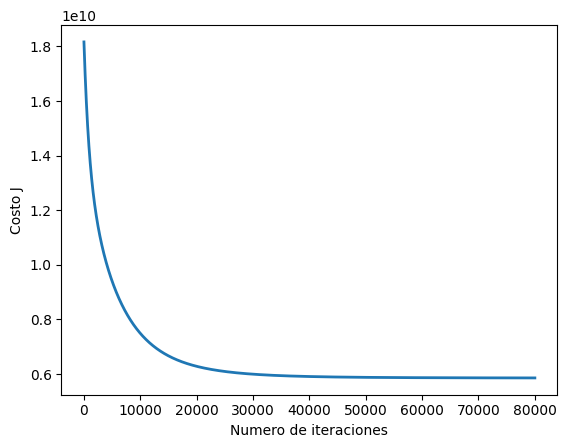

In [37]:
theta = np.zeros(21)

num_ite = 80000
alpha = 0.0001

theta, J_historico = calcularDescensoGradiente(X_ready, y, theta, alpha, num_ite)
print(f"los valores de theta calculados son: { theta }")
print(f"con un costo de: { J_historico[-2]} ")

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_historico)), J_historico, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')


In [38]:
print(X_test[0]) # Accede al primer elemento de X_test (array numpy)
print(y_test.iloc[0]) # Accede al primer elemento de y_test (serie pandas) por su posición

[ 1.         -0.4517896  -0.28145261 -0.68926294 -0.02120646  0.27540106
  0.07340589 -0.21524301 -1.74663474 -0.62601365 -1.08446528  0.67561166
  0.50140596 -0.45208603 -0.35152088 -0.29310344  0.37468587  0.67108301
 -1.04007741  1.03867904 -0.34590062]
16860


## Haciendo una Prediccion

In [39]:
for i in range(10):

    # Predicción usando el ejemplo i
    price = np.dot(X_test[i], theta)

    # Valor real
    real_price = y_test.iloc[i]

    # Mostrar resultados
    print(f'Predicción {i+1}')
    print(f'Precio real: ${real_price:.0f}')
    print(f'Precio predecido: ${price:.0f}')
    print('-----------------------------')

Predicción 1
Precio real: $16860
Precio predecido: $12337
-----------------------------
Predicción 2
Precio real: $17000
Precio predecido: $17655
-----------------------------
Predicción 3
Precio real: $6999
Precio predecido: $4421
-----------------------------
Predicción 4
Precio real: $8190
Precio predecido: $-15146
-----------------------------
Predicción 5
Precio real: $16490
Precio predecido: $12405
-----------------------------
Predicción 6
Precio real: $29977
Precio predecido: $59662
-----------------------------
Predicción 7
Precio real: $14950
Precio predecido: $9264
-----------------------------
Predicción 8
Precio real: $16900
Precio predecido: $11443
-----------------------------
Predicción 9
Precio real: $1000
Precio predecido: $1589
-----------------------------
Predicción 10
Precio real: $14290
Precio predecido: $10348
-----------------------------
